# 📘 Week 3: Fourier Series & Discrete Fourier Transform (DFT)

## 🎯 Objectives:
- Understand Fourier Series and how periodic signals are decomposed into harmonics
- Learn the Discrete Fourier Transform (DFT) and Fast Fourier Transform (FFT)
- Analyze frequency content of signals
- Visualize spectra and interpret results

## 🎵 Creating a Periodic Square Wave
We'll use a square wave to demonstrate Fourier decomposition.

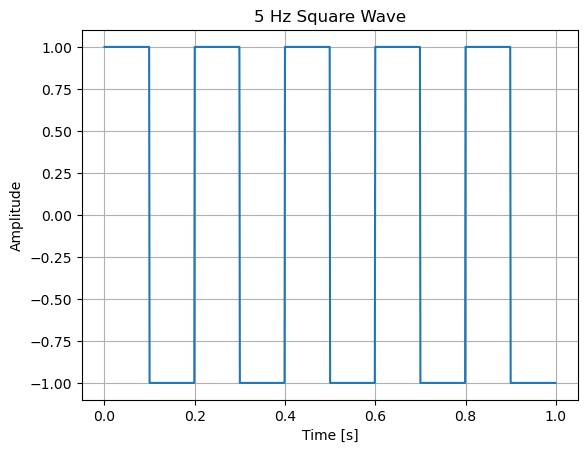

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
square_wave = signal.square(2 * np.pi * 5 * t)

plt.plot(t, square_wave)
plt.title('5 Hz Square Wave')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 🧠 Fourier Series Intuition
- A square wave can be represented as a sum of odd harmonics
- We'll demonstrate how adding harmonics reconstructs the wave

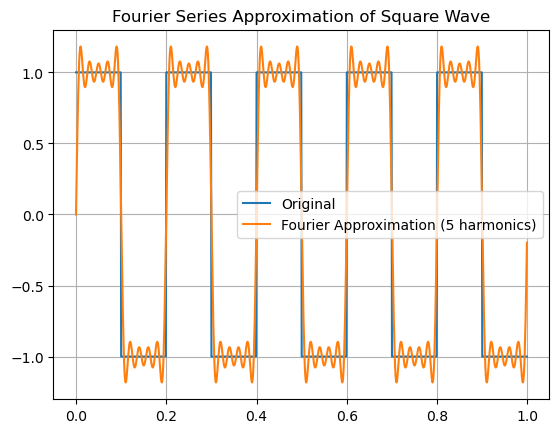

In [2]:
approx = np.zeros_like(t)
for k in range(1, 10, 2):  # 1st to 9th odd harmonics
    approx += (4 / (np.pi * k)) * np.sin(2 * np.pi * k * 5 * t)

plt.plot(t, square_wave, label='Original')
plt.plot(t, approx, label='Fourier Approximation (5 harmonics)')
plt.title('Fourier Series Approximation of Square Wave')
plt.legend()
plt.grid(True)
plt.show()

## ⚡ DFT Using FFT
- Apply FFT to analyze frequency spectrum
- Plot magnitude spectrum

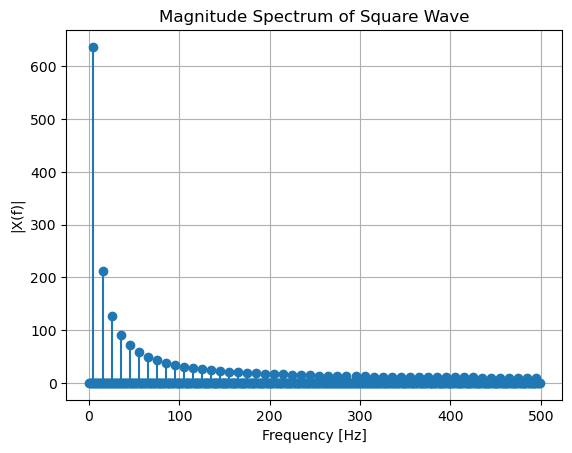

In [3]:
from numpy.fft import fft, fftfreq

X = fft(square_wave)
freqs = fftfreq(len(t), 1/fs)

plt.stem(freqs[:fs//2], np.abs(X)[:fs//2], basefmt=' ')
plt.title('Magnitude Spectrum of Square Wave')
plt.xlabel('Frequency [Hz]')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.show()

## 🔍 Spectral Analysis of Mixed Signal
- Analyze a signal with 3 frequencies: 50 Hz, 120 Hz, 250 Hz

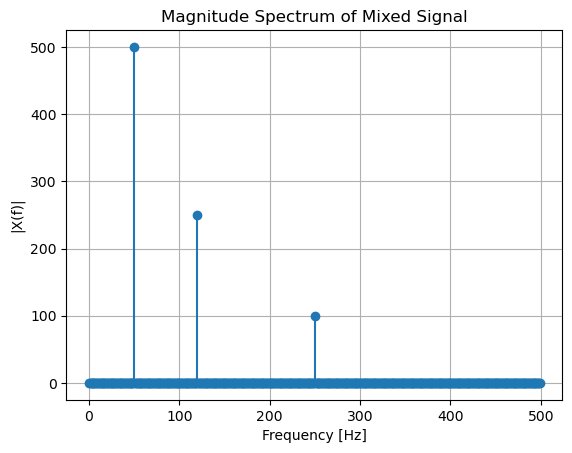

In [4]:
f1, f2, f3 = 50, 120, 250
mixed_signal = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t) + 0.2*np.sin(2*np.pi*f3*t)
X_mixed = fft(mixed_signal)

plt.stem(freqs[:fs//2], np.abs(X_mixed)[:fs//2], basefmt=' ')
plt.title('Magnitude Spectrum of Mixed Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('|X(f)|')
plt.grid(True)
plt.show()

## ✅ Reflection:
- How do Fourier Series help visualize a signal’s structure?
- What does each peak in the spectrum represent?
- How does FFT speed up DFT computation?